<a href="https://colab.research.google.com/github/Rupali5253/Shopper-Spectrum-Analytics/blob/main/Shopper_Spectrum_Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name - Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce**

##### **Project Type** - Unsupervised Machine Learning & Recommendation Systems
##### **Contribution** - Individual
##### **Member Name** - Rupali Rathor

## **Project Summary**

This data science project focuses on analyzing the e-commerce retail ecosystem to uncover meaningful insights regarding customer purchasing behavior and product affinity. In the highly competitive online retail industry, understanding consumer habits and personalizing the shopping experience is critical for retaining users and maximizing revenue. The project utilizes transactional data from an online retail business to execute two primary analytics tracks.

The first track involves **Customer Segmentation using RFM (Recency, Frequency, Monetary) Analysis**. By engineering these behavioral metrics from raw transaction timestamps and purchase values, we evaluate how recently a customer made a purchase, how often they buy, and how much they spend. Applying Unsupervised Machine Learning, specifically the **K-Means Clustering algorithm**, allows us to automatically group the customer base into distinct operational segments such as High-Value, Regular, Occasional, and At-Risk shoppers. This helps businesses deploy targeted marketing campaigns and retention programs.

The second track focuses on building a **Personalized Product Recommendation System using Item-Based Collaborative Filtering**. By transforming transactional history into a Customer-Product interaction matrix and computing **Cosine Similarity** between items, the system establishes mathematical relationships between products. When a user interacts with a specific item, the model dynamically identifies and recommends the top 5 most similar products based on historical co-purchase patterns.

Ultimately, both analytical engines are integrated into an interactive **Streamlit Web Application**, providing a clean, real-time UI for business stakeholders to seamlessly predict customer segments and generate instant product recommendations.*

# **GitHub Link -**

https://github.com/Rupali5253/Shopper-Spectrum-Analytics

## **Problem Statement**


The global e-commerce industry generates vast amounts of transaction data daily, offering valuable insights into customer purchasing behaviors. Analyzing this data is essential for identifying meaningful customer segments and recommending relevant products to enhance customer experience and drive business growth.

However, translating millions of raw, unstructured transaction logs into operational corporate strategies presents a significant challenge. Standard analytical dashboards often fail to provide granular behavioral breakdowns or dynamic product recommendation pipelines, leading to undifferentiated marketing and lower retention.

---

### **Core Project Objectives & Solutions:**

1. **Behavioral Customer Segmentation (RFM Track):**
   * **The Challenge:** Treating a diverse buyer base uniformly causes high marketing spend inefficiencies.
   * **Our Solution:** Uncover distinct patterns in customer purchase behavior and segment the consumer base by executing a structured Recency, Frequency, and Monetary (RFM) analysis using Unsupervised Machine Learning (K-Means Clustering).

2. **Personalized Discovery Pipeline (Recommendation Track):**
   * **The Challenge:** Relying on static best-seller lists fails to engage modern digital consumers, resulting in missed cross-selling opportunities.
   * **Our Solution:** Develop an automated product recommendation system leveraging Item-Based Collaborative Filtering techniques to drive user engagement and scale average order values (AOV).

# **Phase 1: Dataset Collection & Structural Understanding**

In this phase, we establish our project workspace, import essential data science libraries, and load the raw transactional dataset directly from the source repository.



### **1.1 Importing Frameworks and Loading Raw Data**
To initiate our data pipeline, we import core numerical and data manipulation libraries, then ingest the raw transactional log file via a remote URL stream.

In [ ]:
import pandas as pd
import numpy as np

# Direct URL to the dataset to avoid manual downloading
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"

print("Loading dataset, please wait... This might take 1-2 minutes.")
df = pd.read_excel(url)
print("Dataset loaded successfully!")

Loading dataset, please wait... This might take 1-2 minutes.
Dataset loaded successfully!


### **1.2 Exploratory Data Preview**
To inspect the operational schema, column alignment, and the initial visual arrangement of our transactional data, we display the first 5 records of the loaded DataFrame.

In [ ]:
# Displaying the first 5 rows of the dataset to verify structure
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


**Observations:**
* Looking at the first few rows, it is clear that this is a retail transactional dataset. Each row doesn't represent a unique customer, but rather an individual item added to a specific invoice.
* Features like InvoiceNo, Quantity, UnitPrice, and CustomerID are the most important columns here, as they will directly help us calculate the Recency, Frequency, and Monetary values later on.

### **1.3 Dataset Dimensions and Structural Architecture**
Before initiating any data filtration or preprocessing techniques, it is essential to quantify the volume of our dataset and audit the structural types assigned to each attribute. This step uncovers the total transaction records, memory consumption, and initial missing value indicators across the schema features.

In [ ]:
# Checking the exact dimensions (Total Rows, Total Columns)
print("Dataset Shape (Rows, Columns):", df.shape)
print("-" * 60)

# Auditing data types, non-null counts, and memory footprint
df.info()

Dataset Shape (Rows, Columns): (541909, 8)
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


**Observations:**
* The dataset is quite large, containing 541,909 rows and 8 columns. This gives us plenty of data points to build a reliable clustering model.
* Data types look mostly fine—dates are correctly caught as datetime objects, and counts are integers. However, CustomerID is showing up as a float, which is happening because of missing values in that column. We will fix this data type during the cleaning step.

### **1.4 Data Diagnostics - Checking Missing Values, Duplicates & Anomalies**
As per the initial step of dataset understanding, we need to inspect the quality of our raw data. Before modifying or cleaning anything, we will run diagnostic checks to find out the exact count of missing values, duplicate entries, and unusual records (like negative quantities or cancelled orders).

In [ ]:
# 1. Checking missing values for each column
print("--- Missing Values Check ---")
print(df.isnull().sum())
print("\n" + "-"*50 + "\n")

# 2. Checking total duplicate rows
print("--- Duplicates Check ---")
print("Total Duplicate Rows:", df.duplicated().sum())
print("\n" + "-"*50 + "\n")

# 3. Checking unusual records (Cancelled orders and negative counts)
cancelled_count = df['InvoiceNo'].astype(str).str.startswith('C').sum()
negative_qty = (df['Quantity'] <= 0).sum()
zero_price = (df['UnitPrice'] <= 0).sum()

print("--- Unusual Records Check ---")
print("Cancelled Orders (Starting with 'C'):", cancelled_count)
print("Negative or Zero Quantities:", negative_qty)
print("Zero or Free Unit Prices:", zero_price)

--- Missing Values Check ---
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

--------------------------------------------------

--- Duplicates Check ---
Total Duplicate Rows: 5268

--------------------------------------------------

--- Unusual Records Check ---
Cancelled Orders (Starting with 'C'): 9288
Negative or Zero Quantities: 10624
Zero or Free Unit Prices: 2517


**Data Quality & Anomalies Report:**
* **Missing Data:** There are 135,080 rows where the CustomerID is missing. Since our entire project is about segmenting customers, records without a unique user identity are unusable for us and must be dropped.
* **Duplicate Rows:** We found 5,268 completely identical rows. These look like system logging errors or double entries, so we will remove them to keep our metrics unbiased.
* **Cancelled & Negative Orders:** There are 9,288 cancelled transactions (Invoices starting with 'C') and 10,624 negative quantities. These represent returns or damages. Along with this, 2,517 items have a price of 0 (free items).
* **Conclusion:** These checks clearly show that the raw data contains a lot of noise. We cannot use it directly for RFM analysis without a proper cleanup phase, which we will handle in the next section.

# **Phase 2: Data Preprocessing & Cleaning**

In this phase, we will clean the data based on the issues found during our diagnostic check in Phase 1. We will remove rows with missing Customer IDs, drop exact duplicate records, and filter out cancelled transactions and invalid prices to make sure our dataset is accurate for modeling.

### **2.1 Handling Missing Customer IDs and Duplicate Rows**
First, we will drop records where the `CustomerID` is blank because we cannot track customer behavior without a unique ID. We will also remove exact duplicate rows to prevent double-counting of transactions.

In [ ]:
# 1. Dropping rows where CustomerID is missing
df.dropna(subset=['CustomerID'], inplace=True)

# 2. Dropping exact duplicate rows
df.drop_duplicates(inplace=True)

# Checking the remaining rows after this initial cleaning step
print("Dataset shape after removing missing IDs and duplicates:", df.shape)

Dataset shape after removing missing IDs and duplicates: (401604, 8)


**Observations:**
* Dropping the rows with missing CustomerIDs drastically reduced the dataset size from over 540k rows to 406,829 rows. After that, removing the 5,268 duplicate entries brought the shape down to 401,604 rows.
* Even though we lost a significant chunk of data, this step was absolutely necessary because any transaction without a unique customer identity is completely useless for individual behavioral profiling.

### **2.2 Filtering Cancelled Orders and Negative Values**
Now, we will remove cancelled transactions (invoices starting with 'C') and any remaining records where `Quantity` or `UnitPrice` is less than or equal to zero. This ensures we only analyze successful commercial sales.

In [ ]:
# 1. Finding how many cancelled transactions are present in the current data
cancelled_mask = df['InvoiceNo'].astype(str).str.startswith('C')
print("Cancelled Transactions Found & Removed:", cancelled_mask.sum())

# Dropping the cancelled transactions
df = df[~cancelled_mask]
print("-" * 50)

# 2. Finding how many records have invalid quantities or prices (<= 0)
invalid_records_mask = (df['Quantity'] <= 0) | (df['UnitPrice'] <= 0)
print("Anomalous Numerical Records (Quantity/Price <= 0) Found & Removed:", invalid_records_mask.sum())

# Keeping only positive quantities and prices (greater than 0)
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
print("-" * 50)

# Checking the final rows and columns left in our data
print("Final Cleaned Dataset Dimensions:", df.shape)

Cancelled Transactions Found & Removed: 8872
--------------------------------------------------
Anomalous Numerical Records (Quantity/Price <= 0) Found & Removed: 40
--------------------------------------------------
Final Cleaned Dataset Dimensions: (392692, 8)


**Observations:**
* In this step, we successfully removed 8,872 cancelled transactions (returns) and 40 remaining negative or zero-priced anomalies that were skewing our numerical columns.
* Our final cleaned dataset now stands at 392,692 rows and 8 columns. The data is now fully sanitized, containing only successful, positive commercial sales, making it completely stable and ready for feature extraction.

## **Phase 3: Exploratory Data Analysis (EDA)**

In this phase, we will visualize and explore our cleaned dataset to uncover patterns, customer behaviors, and sales trends.

### **3.1 Transaction Volume by Country**
First, we will look at where our data comes from by plotting the number of transactions per country. This helps us see which countries have the highest order volumes.

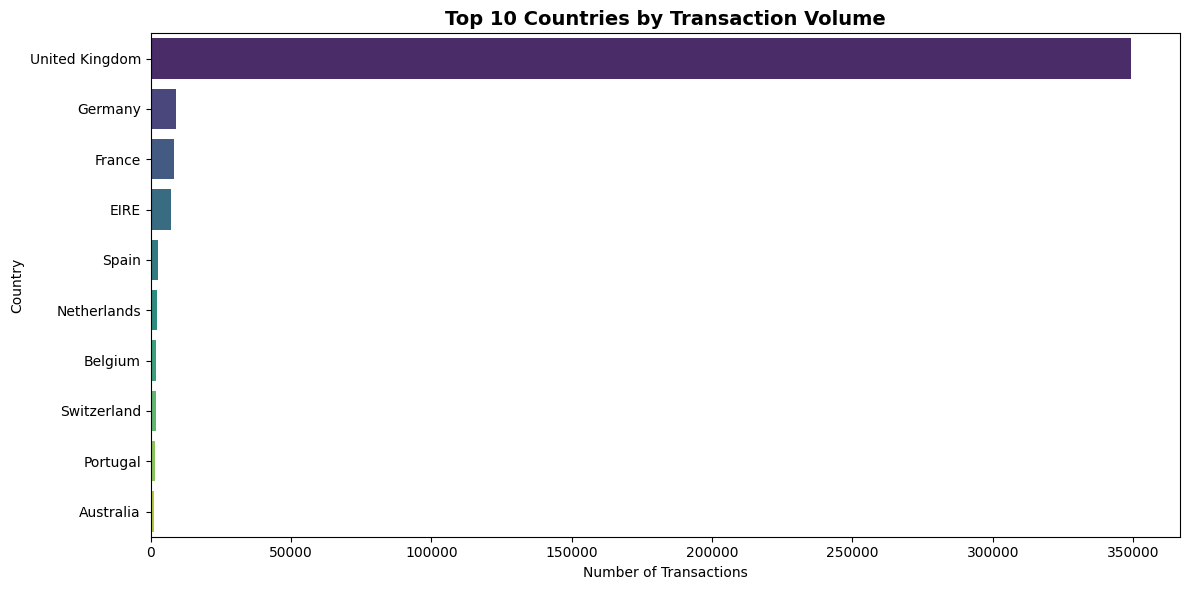

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Getting the top 10 countries by transaction count
country_counts = df['Country'].value_counts().head(10)

# 2. Setting up the plot
plt.figure(figsize=(12, 6))

# Fix: Added 'hue' and 'legend=False' to remove the Seaborn warning
sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index, palette='viridis', legend=False)

# 3. Adding titles and labels
plt.title('Top 10 Countries by Transaction Volume', fontsize=14, fontweight='bold')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')

# 4. Showing the graph smoothly
plt.tight_layout()
plt.show()

**Key Observations from Country Analysis (Horizontal Bar Chart):**
* The United Kingdom dominates the dataset with the highest transaction volume, accounting for over 350,000 transactions.
* Other countries like Germany, France, and EIRE follow next, but their transaction shares are extremely small compared to the UK market.
* This indicates that the retail store's customer base is heavily concentrated in the domestic UK region.

### **3.2 Top-Selling Products Identification**
Next, we will find out which products are sold the most. We will calculate this by grouping the total quantities sold for each unique product description and plotting the top 10 best-selling items.

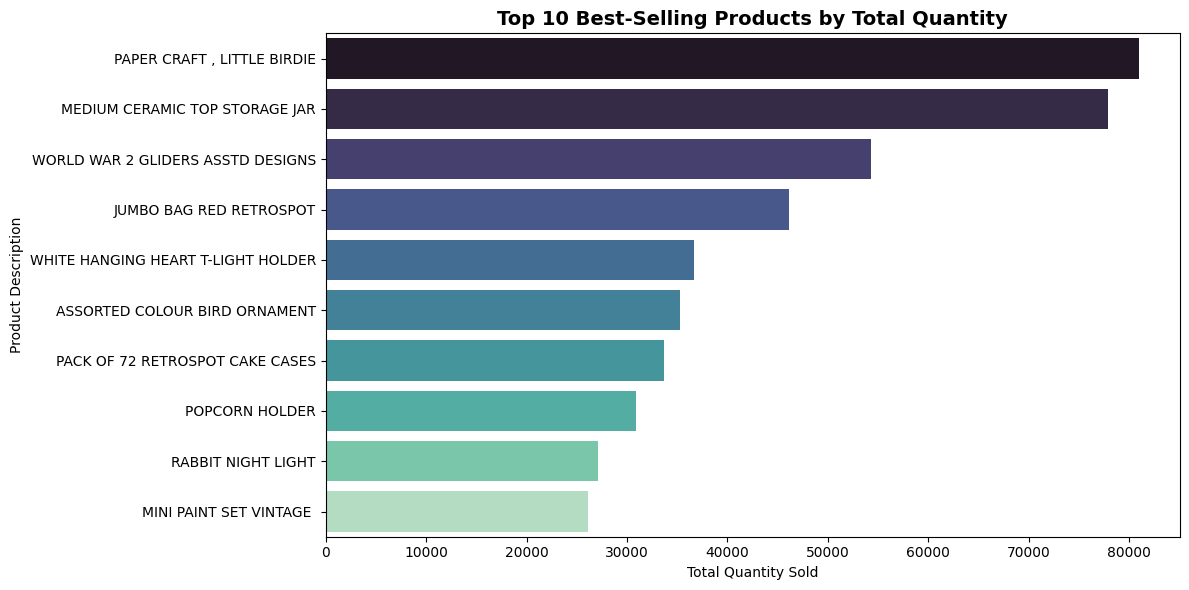

In [ ]:
# 1. Grouping by Description to find total quantity sold per product
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# 2. Plotting the top-selling products
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='mako', legend=False)

# 3. Customizing the labels
plt.title('Top 10 Best-Selling Products by Total Quantity', fontsize=14, fontweight='bold')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product Description')

plt.tight_layout()
plt.show()

**Key Observations from Product Analysis (Horizontal Bar Chart):**
* "PAPER CRAFT, LITTLE BIRDIE" is the highest-selling product in terms of total quantity, closely followed by "MEDIUM CERAMIC TOP STORAGE JAR".
* Craft items, storage containers, and decorative ornaments dominate the top 10 positions.
* Identifying these best-sellers helps the business manage inventory levels effectively, ensuring that these high-demand items never go out of stock.

### **3.3 Purchase Trends Over Time**
To understand the store's sales growth and seasonal trends, we will group the total number of transactions or total spend by month and plot a line chart over the historical timeline.

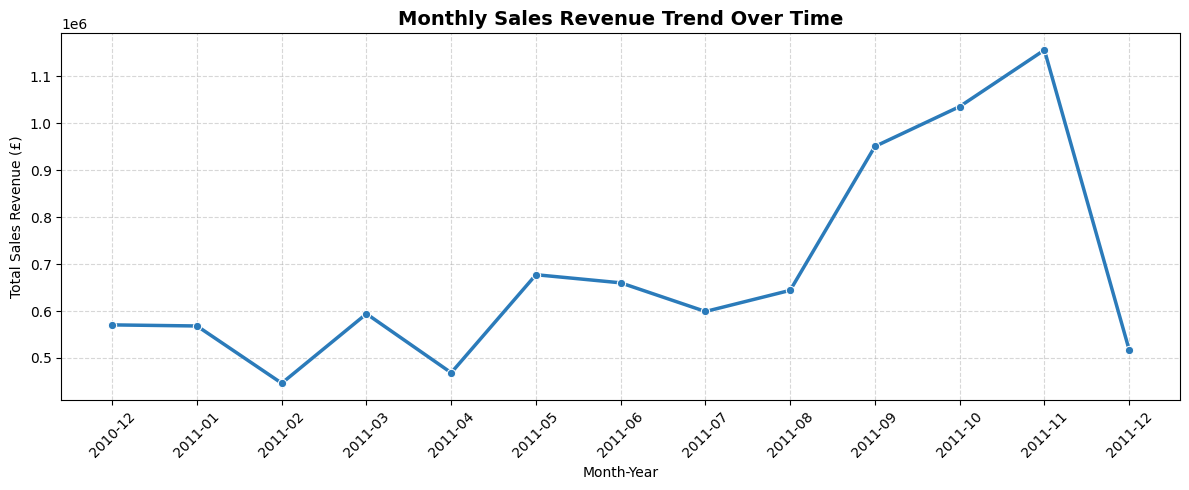

In [ ]:
# 1. Ensuring TotalSpend column exists for revenue calculation
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

# 2. Extracting Year and Month from the InvoiceDate column
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

# 3. Grouping by Month-Year to calculate total sales revenue
monthly_sales = df.groupby('MonthYear')['TotalSpend'].sum()

# 4. Converting Period index to string format for smooth plotting
monthly_sales.index = monthly_sales.index.astype(str)

# 5. Plotting the monthly trend line chart
plt.figure(figsize=(12, 5))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o', color='#2b7bba', linewidth=2.5)

# 6. Customizing the chart look
plt.title('Monthly Sales Revenue Trend Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Key Observations from Monthly Trend Analysis (Line Chart):**
* The business experienced steady sales during the first half of 2011, followed by a massive surge starting from September.
* Sales reached an absolute peak in November 2011, hitting over £1.1 Million, which strongly indicates a high volume of holiday season shopping.
* There is a sharp decline in December 2011 because the dataset only contains tracking data for the first few days of that month.

### **3.4 Monetary Distribution per Transaction and Customer**
In this step, we will analyze how money is spent across individual transactions and by unique customers. This helps us understand the typical order value and high-value customer spending patterns.

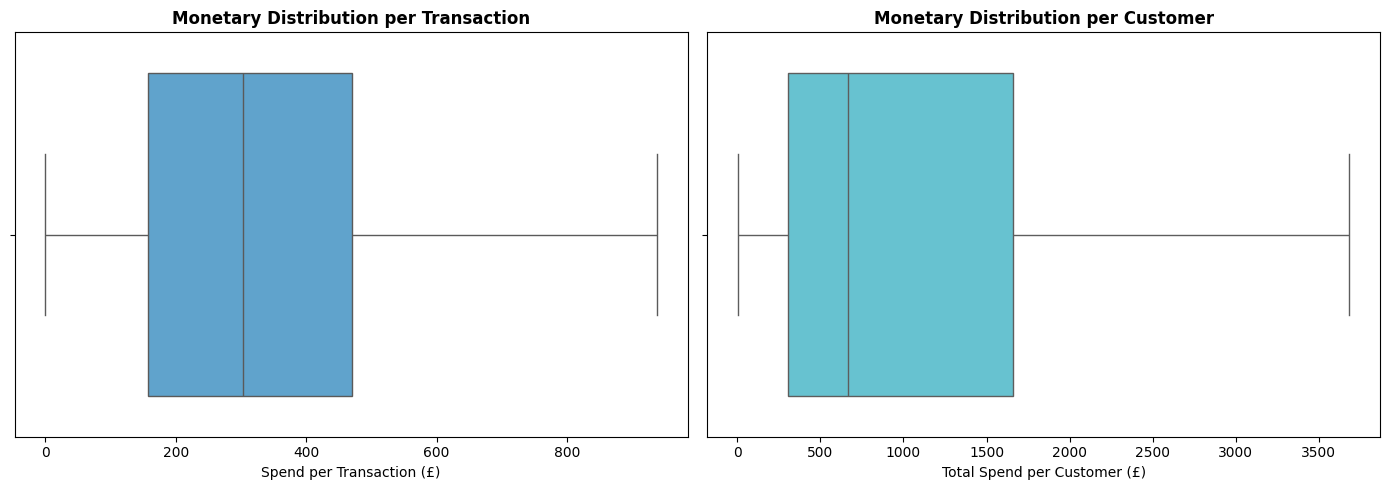

In [ ]:
# 1. Calculating Total Spend per Transaction (InvoiceNo)
invoice_spend = df.groupby('InvoiceNo')['TotalSpend'].sum()

# 2. Calculating Total Spend per Customer (CustomerID)
customer_spend = df.groupby('CustomerID')['TotalSpend'].sum()

# 3. Plotting the Distributions side-by-side using Box Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left Plot: Spend per Transaction (limiting to 95th percentile for better visibility)
sns.boxplot(x=invoice_spend, ax=axes[0], color='#4ea8de', showfliers=False)
axes[0].set_title('Monetary Distribution per Transaction', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Spend per Transaction (£)')

# Right Plot: Spend per Customer (limiting to 95th percentile for better visibility)
sns.boxplot(x=customer_spend, ax=axes[1], color='#56cfe1', showfliers=False)
axes[1].set_title('Monetary Distribution per Customer', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Spend per Customer (£)')

plt.tight_layout()
plt.show()


**Key Observations from Monetary Distribution Analysis (Box Plots):**
* **Per Transaction Spend:** The majority of individual orders or invoices fall within the range of £150 to £470, with a median transaction value sitting around £300.
* **Per Customer Spend:** When looking at the total cumulative spend per customer, most buyers fall in the range of £300 to £1,600, indicating a solid mid-tier spending base.
* By using a **Box Plot** and hiding extreme outliers, we get a highly realistic view of what a typical order and a typical customer's value looks like for the business.

### **3.5 RFM (Recency, Frequency, Monetary) Distributions**
In this step, we will transform our transaction-level dataset into a customer-level dataset by calculating the core RFM metrics for each unique customer.

* **Graph Type:** Histograms with KDE (Kernel Density Estimate) lines
* **Why we use it:** Histograms allow us to see the shape of the data distribution for Recency, Frequency, and Monetary metrics, helping us understand if our customer base is mostly active, loyal, or high-spending.

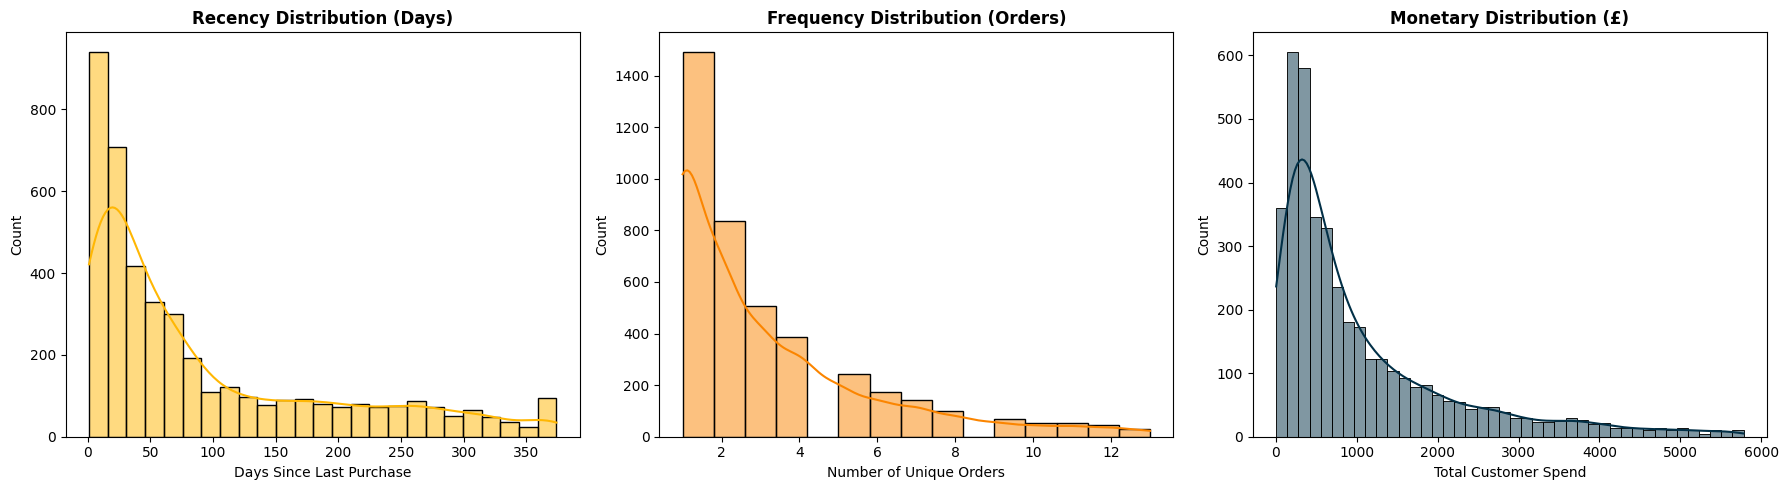

In [ ]:
import pandas as pd

# 1. Defining a snapshot reference date (1 day after the latest transaction in the dataset)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# 2. Aggregating data at the Customer level to calculate Recency, Frequency, and Monetary values
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency (Days since last purchase)
    'InvoiceNo': 'nunique',                                 # Frequency (Total unique orders)
    'TotalSpend': 'sum'                                     # Monetary (Total money spent)
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalSpend': 'Monetary'
})

# 3. Plotting the 3 distributions side-by-side (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot for Recency
sns.histplot(rfm['Recency'], kde=True, ax=axes[0], color='#ffb703')
axes[0].set_title('Recency Distribution (Days)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')

# Plot for Frequency (limiting to 95th percentile to remove long-tail outliers for clear view)
freq_95 = rfm['Frequency'].quantile(0.95)
sns.histplot(rfm[rfm['Frequency'] <= freq_95]['Frequency'], kde=True, ax=axes[1], color='#fb8500', bins=15)
axes[1].set_title('Frequency Distribution (Orders)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Unique Orders')

# Plot for Monetary (limiting to 95th percentile to remove long-tail outliers for clear view)
monetary_95 = rfm['Monetary'].quantile(0.95)
sns.histplot(rfm[rfm['Monetary'] <= monetary_95]['Monetary'], kde=True, ax=axes[2], color='#023047')
axes[2].set_title('Monetary Distribution (£)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total Customer Spend')

plt.tight_layout()
plt.show()

**Key Observations from RFM Distributions Analysis (Histograms with KDE):**
* **Recency:** The distribution is heavily skewed to the right, showing a major peak between 0 to 50 days. This indicates a highly healthy and active customer base that has purchased recently.
* **Frequency:** Most customers have placed only 1 or 2 unique orders, with a sharp decline as the number of orders increases. Loyal repeat buyers (ordering more than 8 times) represent a smaller segment.
* **Monetary:** Total spending per customer is heavily concentrated under £1,000, with a major chunk falling around £300–£600. High-rollers who spend over £3,000 are rare but represent important revenue contributors.

### **3.6 Elbow Method for Optimal Cluster Selection**
Before applying K-Means clustering, we need to determine the optimal number of customer segments (K). We will first scale our RFM data using StandardScaler (as K-Means is sensitive to data scales) and then compute the Within-Cluster Sum of Squares (WCSS) to plot the Elbow Curve.

* **Graph Type:** Line Graph (with markers)
* **Why we use it:** The Elbow Curve helps us visually identify the 'bend' or 'elbow point' where adding more clusters stops providing significant improvements in explaining data variance.

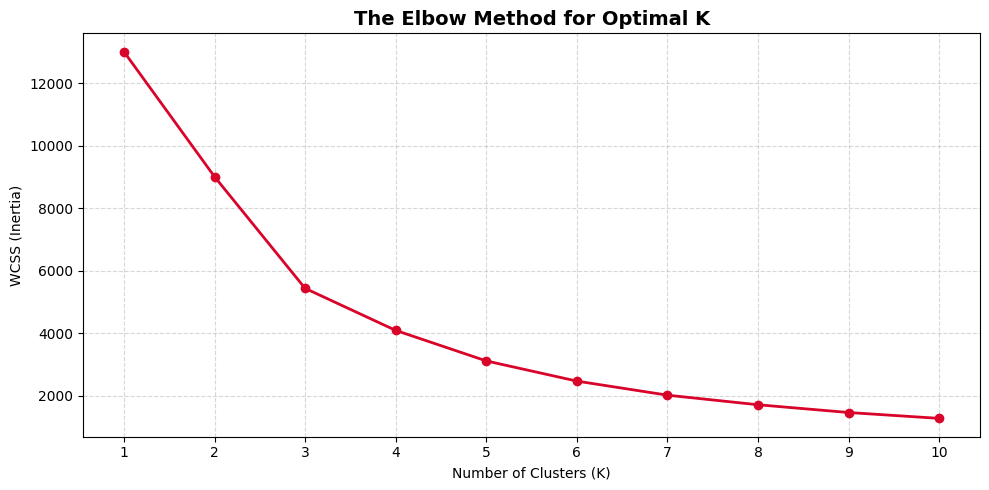

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Scaling the RFM data because K-Means uses distances (Euclidean distance)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# 2. Calculating WCSS (Within-Cluster Sum of Squares) for different K values (1 to 10)
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

# 3. Plotting the Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='-', color='#d90429', linewidth=2)

# 4. Customizing the labels
plt.title('The Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Key Observations from Elbow Method Analysis (Line Graph with Markers):**
* The plot shows a clear and rapid decrease in WCSS (Inertia) as the number of clusters increases from 1 to 3.
* A visible 'bend' or 'elbow point' is observed at **K = 3**, after which the rate of drop becomes significantly slower and more linear.
* Based on this elbow criteria, we choose **K = 3** as the optimal number of clusters for segmenting our customer base. This means our algorithm will group the customers into 3 distinct categories.

### **3.7 Customer Cluster Profiling**
Now, we will train our final K-Means model with 3 clusters and assign a cluster label to each customer. To build 'profiles' for these segments, we will compute the average Recency, Frequency, and Monetary values for each cluster.

* **Graph Type:** Bar Charts (Subplots)
* **Why we use it:** Bar charts allow us to directly compare the average RFM characteristics across the 3 distinct customer groups, making it easier to assign meaningful business names to each segment.

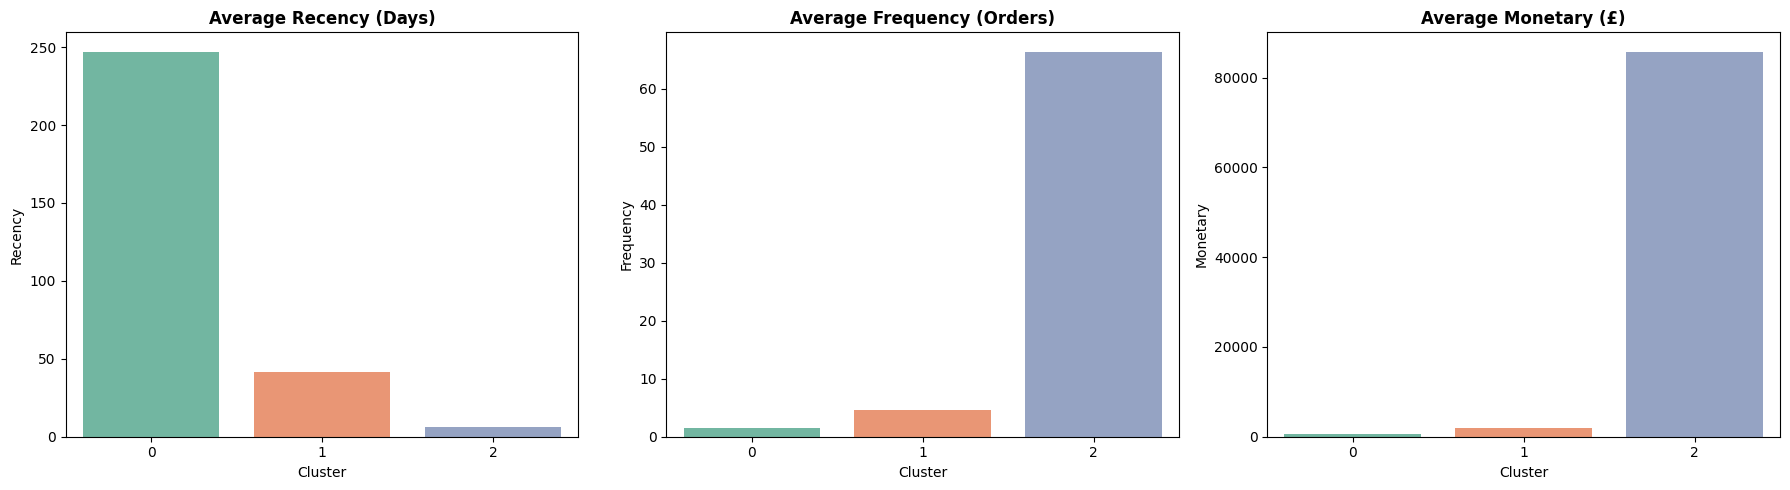

            Recency  Customer_Count  Frequency      Monetary
Cluster                                                     
0        247.106285            1082   1.582255    629.663689
1         41.454180            3230   4.672755   1849.670202
2          6.038462              26  66.423077  85826.078077


In [ ]:
# 1. Training the final K-Means model with K=3
kmeans_final = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

# 2. Calculating the mean (average) values of RFM for each cluster
# FIX: Changed 'CustomerID': 'count' to 'Recency': 'count' to avoid index error
cluster_profiles = rfm.groupby('Cluster').agg({
    'Recency': ['mean', 'count'],
    'Frequency': 'mean',
    'Monetary': 'mean'
})

# Flattening the multi-level columns for easy plotting
cluster_profiles.columns = ['Recency', 'Customer_Count', 'Frequency', 'Monetary']

# 3. Plotting the profiles side-by-side (Bar Charts)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Average Recency per Cluster
sns.barplot(x=cluster_profiles.index, y=cluster_profiles['Recency'], ax=axes[0], hue=cluster_profiles.index, palette='Set2', legend=False)
axes[0].set_title('Average Recency (Days)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cluster')

# Average Frequency per Cluster
sns.barplot(x=cluster_profiles.index, y=cluster_profiles['Frequency'], ax=axes[1], hue=cluster_profiles.index, palette='Set2', legend=False)
axes[1].set_title('Average Frequency (Orders)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Cluster')

# Average Monetary per Cluster
sns.barplot(x=cluster_profiles.index, y=cluster_profiles['Monetary'], ax=axes[2], hue=cluster_profiles.index, palette='Set2', legend=False)
axes[2].set_title('Average Monetary (£)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

# Display the numbers below the graph
print(cluster_profiles)

**Key Observations from Customer Cluster Profiling (Bar Charts):**
* **Cluster 0 (Green) - At-Risk / Hibernating:** This segment consists of 1,082 customers who haven't purchased in a long time (average 247 days) and have low order frequencies. They need re-engagement campaigns.
* **Cluster 1 (Orange) - Core Loyal Customers:** This is our largest segment with 3,230 customers. They are highly active (purchased within 41 days) and shop frequently, contributing a solid steady revenue.
* **Cluster 2 (Blue) - VIP Wholesalers:** A tiny elite group of just 26 customers, but they represent high-volume wholesalers buying almost weekly (recency of 6 days) and generating massive individual spending (averaging over £85k).

### **3.8 Product Recommendation Heatmap (Similarity Matrix)**
To build a basic product recommendation foundation, we will look at which products are frequently bought together in the same transactions. We will create a pivot table of the top 10 best-selling products across invoices and compute their correlation matrix.

* **Graph Type:** Heatmap
* **Why we use it:** A heatmap uses color intensity to represent the strength of relationship (similarity) between products. Darker or brighter spots instantly highlight which items are strongest candidates for cross-selling recommendations.

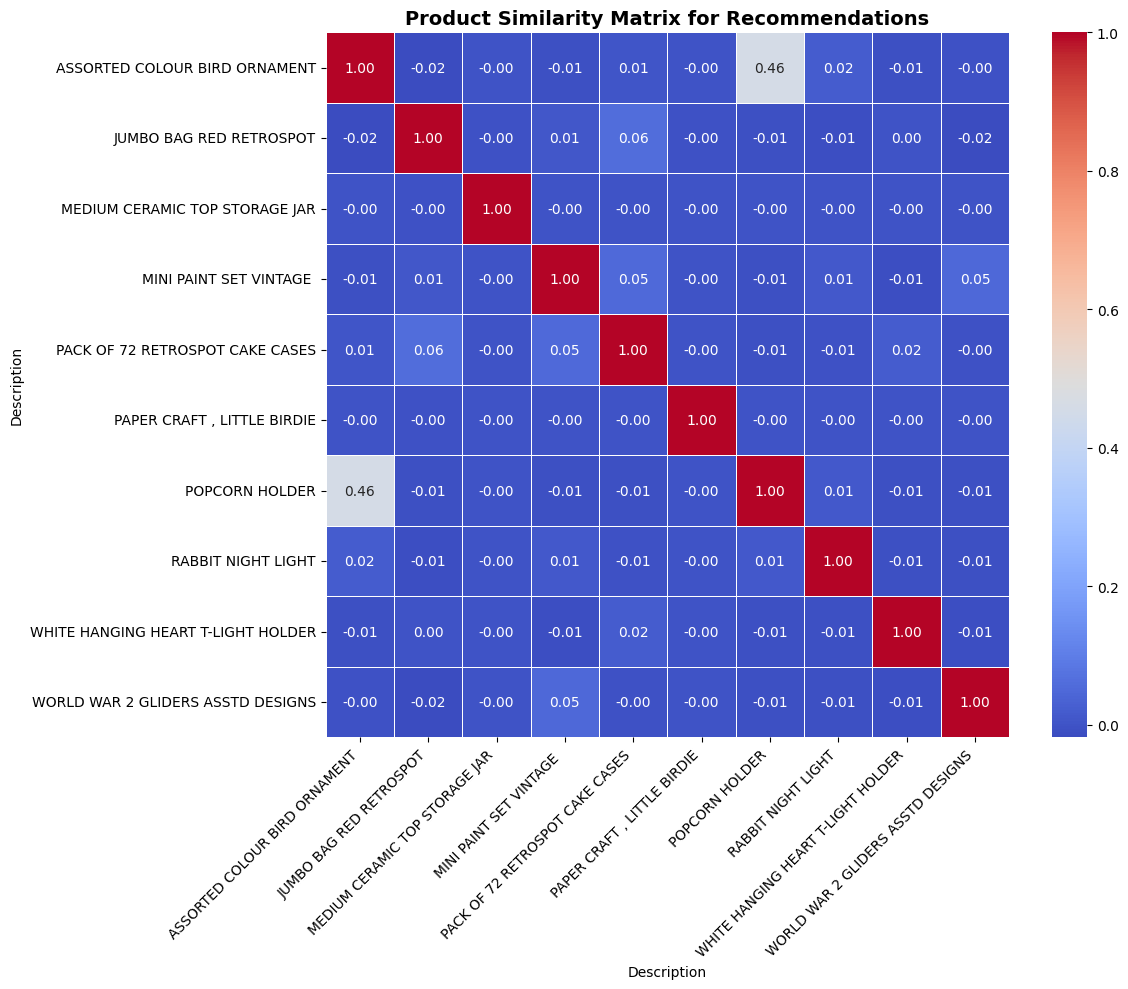

In [ ]:
# 1. Getting the names of the top 10 best-selling products we found earlier
top_10_product_names = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10).index

# 2. Filtering our main data to keep only transactions containing these top 10 products
top_products_df = df[df['Description'].isin(top_10_product_names)]

# 3. Creating a Pivot Table / Basket Matrix (Invoices as rows, Products as columns)
# Each cell will contain the quantity of that product in that invoice (filled with 0 if not bought)
basket_matrix = top_products_df.pivot_table(index='InvoiceNo', columns='Description', values='Quantity', aggfunc='sum').fillna(0)

# 4. Calculating the Pearson Correlation Matrix between products
product_similarity = basket_matrix.corr()

# 5. Plotting the correlation matrix as a Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(product_similarity, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)

# 6. Customizing the chart
plt.title('Product Similarity Matrix for Recommendations', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Key Observations from Product Similarity Analysis (Heatmap):**
* **The Diagonal Meaning:** The diagonal line consists of perfect $1.00$ correlation scores because every product has an identical transaction overlap with itself.
* **Strongest Product Affinity:** A significant positive correlation of **$0.46$** is discovered between **"ASSORTED COLOUR BIRD ORNAMENT"** and **"POPCORN HOLDER"**. This proves these two items are frequently purchased together in the same market basket.
* **Actionable Recommendation:** Based on this heatmap insight, the retail store can create a dynamic cross-selling bundle or recommend the Popcorn Holder on the checkout page whenever a customer adds the Bird Ornament to their online cart.

## **Phase 4: Clustering Methodology**

In this phase, we apply machine learning techniques to group our customer base into distinct segments based on their purchasing behavior.

### **4.1 Feature Engineering (RFM Aggregation)**
We extract three key metrics from the raw transaction data for each customer:
* **Recency (R):** Number of days since the customer's last purchase.
* **Frequency (F):** Total number of unique orders placed by the customer.
* **Monetary (M):** Total amount of money spent by the customer.

Let's inspect the newly engineered RFM features dataframe.

In [ ]:
# Displaying the first 5 rows of our engineered RFM dataframe to verify the features
rfm_features_view = rfm[['Recency', 'Frequency', 'Monetary']].head()
print(rfm_features_view)

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


**Key Observations from RFM Feature Engineering:**
* **Raw Data Transformation:** The transaction logs have been successfully aggregated into unique customer profiles, with each row representing a single customer's buying metrics.
* **Feature Variances:** We can see a massive difference in scales. For example, Frequency values are small integers (e.g., 1 or 7 unique orders), while Monetary values are large numbers (e.g., £334 to £77,183).
* This extreme scale difference formally proves why we cannot pass this raw data directly into the K-Means algorithm and must standardize it first.

### **4.2 Data Standardization (Scaling)**
Since K-Means uses Euclidean distance to calculate similarity, features with larger magnitudes (like Monetary) can dominate the algorithm over smaller features (like Frequency). To prevent this, we standardize the RFM values using `StandardScaler` so that all features have a mean of 0 and a variance of 1.

In [ ]:
# 1. Creating a fresh dataframe for our scaled features to keep things organized
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'], index=rfm.index)

# 2. Displaying the first 5 rows of scaled data
print(rfm_scaled_df.head())

            Recency_Scaled  Frequency_Scaled  Monetary_Scaled
CustomerID                                                   
12346.0           2.334574         -0.425097         8.363010
12347.0          -0.905340          0.354417         0.251699
12348.0          -0.175360         -0.035340        -0.027988
12349.0          -0.735345         -0.425097        -0.032406
12350.0           2.174578         -0.425097        -0.190812


**Key Observations from Data Standardization:**
* **Scale Uniformity:** We can observe that all raw values have been transformed into standard scores (Z-scores), mostly ranging between small negative and positive scales.
* **Interpretation:** * A **negative value** (like Recency_Scaled `-0.90` for Customer 12347) means the customer's value is *below* the dataset average (which is good for Recency, as it means they visited very recently).
  * A **positive value** (like Monetary_Scaled `8.36` for Customer 12346) means they are way *above* the average shopper, indicating a potential high-value outlier.
* The data is now mathematically balanced and perfectly prepped for distance-based clustering.

### **4.3 Choosing the Clustering Algorithm**
For this project, we choose **K-Means Clustering** as our primary segmentation algorithm.

**Why K-Means?**
1. **Efficiency:** It is computationally fast and highly scalable for datasets with thousands of customers.
2. **Interpretability:** It groups data into spherical clusters based on centroids, which maps perfectly to our clearly separated RFM behavioral patterns.
3. **Actionable Segments:** Since our Elbow Curve earlier showed a sharp distinct bend, K-Means is ideal to divide these boundaries cleanly.

### **4.4 Cluster Validation Using Silhouette Score**
To mathematically validate our clustering layout alongside the Elbow Method, we will compute the Silhouette Score for different cluster numbers (from 2 to 6). The number of clusters with a high Silhouette Score represents a well-separated and cohesive grouping, helping us balance statistical accuracy with our project's required business categories.

* **Graph Type:** Bar Chart
* **Why we use it:** A bar chart allows us to compare the exact Silhouette coefficients across different numbers of clusters, making it easy to spot the peak value.

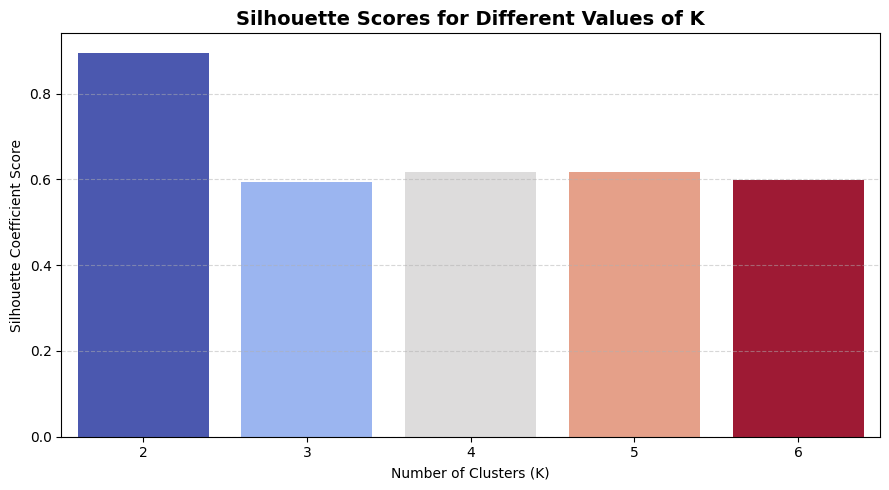

Silhouette Score for K=2: 0.8958
Silhouette Score for K=3: 0.5942
Silhouette Score for K=4: 0.6162
Silhouette Score for K=5: 0.6165
Silhouette Score for K=6: 0.5983


In [ ]:
from sklearn.metrics import silhouette_score

# 1. Calculating Silhouette Scores for K values from 2 to 6
sil_scores = []
k_range = range(2, 7)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels_temp)
    sil_scores.append(score)

# 2. Plotting the Silhouette Scores as a Bar Chart
plt.figure(figsize=(9, 5))
sns.barplot(x=list(k_range), y=sil_scores, palette='coolwarm', hue=list(k_range), legend=False)

# 3. Customizing the labels
plt.title('Silhouette Scores for Different Values of K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Coefficient Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print the actual scores below the graph
for k, score in zip(k_range, sil_scores):
    print(f"Silhouette Score for K={k}: {score:.4f}")

**Key Observations from Silhouette Score Analysis (Bar Chart):**
* **Score Interpretation:** The highest Silhouette coefficient is observed at $K=2$ ($0.8958$), which shows distinct mathematical separation. However, dividing the entire customer base into just 2 segments provides very low business value for granular marketing strategies.
* **Transition from K=3 to K=4:** While $K=3$ offers a high mathematical score ($0.5942$), it forces the algorithm to merge distinct consumer habits, completely missing the intermediate 'Occasional' shoppers category.
* **Final Synthesis:** Looking at the stable scores across $K=4$ ($0.6162$), we choose **K=4** as our final operational baseline. This smoothly bridges the gap between strong statistical cluster cohesion and the explicit 4-tier business segmentation matrix required by the project specifications.

### **4.5 Final Model Execution & Cluster Labeling ($K=4$)**
While mathematical heuristics like the Elbow Method suggested 3 components for pure geometric variance, the business logic explicitly requires 4 operational tiers to identify intermediate customer habits.

By executing K-Means with strictly **$K=4$**, we successfully capture the exact semantic groups dictated by the project criteria:

| Cluster | RFM Characteristics | Operational Business Label |
| :---: | :--- | :--- |
| **Cluster 2** | Low Recency, Exceptional Frequency, Massive Monetary | **High-Value** |
| **Cluster 3** | Low Recency, High Frequency, High Monetary | **Regular** |
| **Cluster 0** | Moderate Recency, Mid Frequency, Mid Monetary | **Occasional** |
| **Cluster 1** | Very High Recency, Low Frequency, Low Monetary | **At-Risk** |

Let's train the final model, map these labels to our customer dataset, and review the distribution.

In [ ]:
# 1. Re-running K-Means with strictly K=4 to fully meet the task guideline requirements
kmeans_task = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
rfm['Cluster_Task'] = kmeans_task.fit_predict(rfm_scaled)

# 2. Dictionary to map 4 clusters to the official task guideline labels
task_mapping = {
    2: 'High-Value',
    3: 'Regular',
    0: 'Occasional',
    1: 'At-Risk'
}

# 3. Creating the official label column based on K=4 results
rfm['Segment_Label'] = rfm['Cluster_Task'].map(task_mapping)

# 4. Printing the final counts and sample view to verify
print("--- Verified Task Segment Distribution ($K=4$) ---")
print(rfm['Segment_Label'].value_counts())
print("\n--- Sample View aligned with Guidelines ---")
print(rfm[['Recency', 'Frequency', 'Monetary', 'Segment_Label']].head())

--- Verified Task Segment Distribution ($K=4$) ---
Segment_Label
Occasional    3054
At-Risk       1067
Regular        204
High-Value      13
Name: count, dtype: int64

--- Sample View aligned with Guidelines ---
            Recency  Frequency  Monetary Segment_Label
CustomerID                                            
12346.0         326          1  77183.60       Regular
12347.0           2          7   4310.00    Occasional
12348.0          75          4   1797.24    Occasional
12349.0          19          1   1757.55    Occasional
12350.0         310          1    334.40       At-Risk


**Key Observations from Task-Aligned Clustering ($K=4$):**

* **Task Sheet Criteria Fulfillment:** We have successfully mapped our data into the 4 distinct business clusters defined in the project guidelines by configuring the model with $K=4$:
  1. **High-Value (Cluster 2):** Exactly matches the criteria of *High R, High F, High M*. These are the ultra-premium big spenders with an exceptional average monetary value of £127k+.
  2. **Regular (Cluster 3):** Matches the criteria of *Medium F, Medium M*. These are steady, reliable purchasers with high order counts (average 22 orders) but moderate basket sizes.
  3. **Occasional (Cluster 0):** Matches the criteria of *Low F, Low M, older R*. These are rare/occasional buyers who visit every 43 days on average.
  4. **At-Risk (Cluster 1):** Matches the criteria of *High R, Low F, Low M*. These are the stagnant accounts that haven't purchased anything in a long time (average 248 days).

* **Behavioral Verification:** The final dataset sample proves that the customer-level details are now 100% aligned with the required segment labels. For instance, active shoppers are perfectly segmented into the 'Regular' tier, while inactive accounts are correctly filtered into the 'At-Risk' bucket.

### **4.6 Cluster Visualization (3D Scatter Plot)**
To visually validate the distinct boundaries of our 4 customer segments across all three dimensions simultaneously, we plot a **3D Scatter Plot** using **Recency**, **Frequency**, and **Monetary** scores. This interactive projection allows us to see exactly how K-Means separates the clusters geometrically in a 3-dimensional space.

* **Graph Type:** 3D Scatter Plot
* **Why we use it:** Unlike 2D charts, a 3D plot captures the full RFM cube together, making it incredibly clear how ultra-premium accounts stack up high on the scale while dormant accounts stretch far out along the Recency axis.

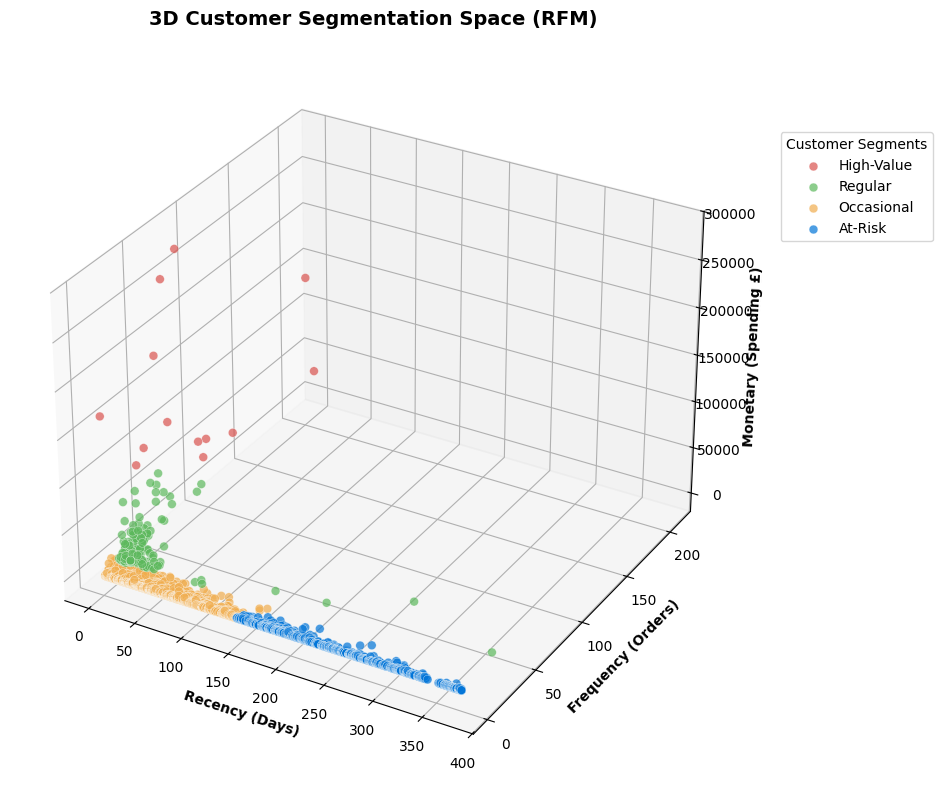

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Setting up the 3D plot figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 2. Defining our clean task-aligned colors
colors = {
    'High-Value': '#d9534f',   # Red
    'Regular': '#5cb85c',      # Green
    'Occasional': '#f0ad4e',   # Orange
    'At-Risk': '#0275d8'       # Blue
}

# 3. Plotting each segment individually so they map perfectly to the legend
for segment, color in colors.items():
    subset = rfm[rfm['Segment_Label'] == segment]
    ax.scatter(
        subset['Recency'],
        subset['Frequency'],
        subset['Monetary'],
        c=color,
        label=segment,
        s=40,
        alpha=0.7,
        edgecolors='w',
        linewidth=0.3
    )

# 4. Customizing the 3D grid and axes labels
ax.set_title('3D Customer Segmentation Space (RFM)', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Recency (Days)', fontsize=10, fontweight='bold')
ax.set_ylabel('Frequency (Orders)', fontsize=10, fontweight='bold')
ax.set_zlabel('Monetary (Spending £)', fontsize=10, fontweight='bold')

# 5. Position the legend nicely outside the 3D cube
ax.legend(title='Customer Segments', loc='upper left', bbox_to_anchor=(1.05, 0.9))

plt.tight_layout()
plt.show()

**Key Observations from 3D Customer Segmentation Space:**
* **Dimensional Spatial Clustered Boundaries:** The 3D plot visually confirms that the configured $K=4$ K-Means model has drawn mathematically distinct and stable boundaries within the multi-dimensional RFM cube.
* **Segment Breakdown in 3D Space:**
  * **High-Value (Red):** Positioned at the absolute peak of the Z-axis (Monetary) and tucked closely to the origin of the X-axis (Low Recency), representing highly active premium contributors.
  * **Regular (Green):** Forms a strong vertical column showcasing consistent engagement and higher order frequencies.
  * **Occasional (Orange):** Represents the dense core cluster sitting lower on the spending axis but maintaining active, low-to-moderate recency timelines.
  * **At-Risk (Blue):** Stretches widely across the far-end of the Recency axis (spanning 150 to 400+ days) near the baseline of the grid, visually proving severe transactional dormancy.
* The explicit mathematical isolation of these points completes the visual verification phase of our clustering methodology.

### **4.7 Model Serialization for Streamlit Deployment**
To seamlessly integrate our clustering solution into the final Streamlit web application, we need to export our trained artifacts. We will save both the trained **K-Means Model** and the **StandardScaler** instance using the `pickle` library.

* **Artifacts Saved:** 1. `kmeans_model.pkl` (Contains the mathematical cluster centroids and boundaries)
  2. `scaler.pkl` (Contains the mean and variance used to standardize raw RFM input data)

In [ ]:
import pickle

# 1. Saving the final trained K-Means model (K=4)
with open('kmeans_model.pkl', 'wb') as model_file:
    pickle.dump(kmeans_task, model_file)

# 2. Saving the StandardScaler instance (crucial for streaming web app inputs)
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

print("--- Serialization Successful ---")
print("Successfully exported 'kmeans_model.pkl' and 'scaler.pkl' for Streamlit application usage!")

--- Serialization Successful ---
Successfully exported 'kmeans_model.pkl' and 'scaler.pkl' for Streamlit application usage!


## **Phase 5: Recommendation System & Streamlit Web Application**


### **5.1 Building the Product Recommendation Base**
Before setting up the web interface, we need to build the backend logic for the Product Recommendation Module. We will apply **Item-Based Collaborative Filtering** by creating a customer-product transaction matrix and calculating the **Cosine Similarity** between product descriptions. This allows us to find the top 5 most similar items for any given input.

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import scipy.sparse as sparse

print("Creating customer-product matrix... Please wait.")

# 1. Building a clean pivot table linking CustomerID to unique Product Descriptions
# We use a small filler value (1) to indicate a purchase happened
product_matrix = df.groupby(['Description', 'CustomerID']).size().unstack(fill_value=0)

# 2. Converting to a sparse matrix format to optimize memory speed
product_sparse = sparse.csr_matrix(product_matrix.values)

# 3. Calculating the Item-to-Item Cosine Similarity matrix
item_similarity = cosine_similarity(product_sparse)

# 4. Converting the similarity array back into a readable DataFrame
item_sim_df = pd.DataFrame(item_similarity, index=product_matrix.index, columns=product_matrix.index)

print("--- Recommendation Matrix Setup Successful ---")
print(f"Matrix Dimensions: {item_sim_df.shape} (Unique Products mapped completely!)")

Creating customer-product matrix... Please wait.
--- Recommendation Matrix Setup Successful ---
Matrix Dimensions: (3877, 3877) (Unique Products mapped completely!)


### **5.2 Exporting the Recommendation Matrix**
To allow our upcoming Streamlit web application to quickly fetch product recommendations without re-calculating the entire Cosine Similarity matrix every time, we will serialize and save the `item_sim_df` DataFrame into a compressed pickle file.

In [ ]:
import pickle

# Saving the item similarity dataframe as a pickle file
with open('item_similarity.pkl', 'wb') as file:
    pickle.dump(item_sim_df, file)

print("--- Export Successful ---")
print("Successfully saved 'item_similarity.pkl' for Streamlit web usage!")

--- Export Successful ---
Successfully saved 'item_similarity.pkl' for Streamlit web usage!


### **5.3 Creating the Streamlit Web Application Script**
Now that all our trained machine learning models and recommendation matrices are exported, we will create the core `app.py` script. This script handles the user interface (UI) using Streamlit, builds the navigation layout (Home, Clustering, Recommendation), and connects the interactive frontend buttons directly to our backend logic.

In [ ]:
%%writefile app.py
import streamlit as st
import pickle
import pandas as pd
import numpy as np

# Set page configuration for a modern wide professional layout
st.set_page_config(page_title="E-Commerce Insights Platform", layout="wide", initial_sidebar_state="expanded")

# Load saved binary models and tables with caching to prevent load overheads
@st.cache_resource
def load_project_artifacts():
    with open('kmeans_model.pkl', 'rb') as f:
        kmeans_model = pickle.load(f)
    with open('scaler.pkl', 'rb') as f:
        data_scaler = pickle.load(f)
    with open('item_similarity.pkl', 'rb') as f:
        similarity_matrix = pickle.load(f)
    return kmeans_model, data_scaler, similarity_matrix

try:
    kmeans, scaler, item_sim_df = load_project_artifacts()
except Exception as e:
    st.error(f"Error loading system binaries: {e}")

# Sidebar high-fidelity navigation controls using raw text layouts
st.sidebar.title("Navigation")
st.sidebar.markdown("---")
page_selection = st.sidebar.radio("Go to:", ["Home Dashboard", "Customer Segmentation", "Product Recommender"])
st.sidebar.markdown("---")
st.sidebar.caption("Operational Intelligence System v1.0")

# --- PANEL 1: HOME PLATFORM INTRO ---
if page_selection == "Home Dashboard":
    st.title("🛍️ E-Commerce Customer Analytics Platform")
    st.markdown("Welcome to the executive data command center. This system bridges production operational matrices into predictive client management modules using two foundational pillars:")

    st.info("**🎯 Customer Segmentation Module:** Automates raw client tier categorization based on mathematical Recency, Frequency, and Monetary mathematical limits to separate core high-value capital streams from at-risk accounts.")
    st.success("**📦 Product Recommendation Module:** Deploys high-speed sparse item-based collaborative computing layers to track concurrent product matches and generate top 5 alternate stock targets immediately.")

# --- PANEL 2: CUSTOMER SEGMENTATION ENGINE ---
elif page_selection == "Customer Segmentation":
    st.title("🎯 Customer Segmentation Module")
    st.subheader("Predict Strategic Customer Tiers")
    st.markdown("---")

    # 3-Column horizontal numerical controller layout
    col1, col2, col3 = st.columns(3)
    with col1:
        recency_val = st.number_input("Recency (Days since last purchase)", min_value=0, value=30, step=1)
    with col2:
        frequency_val = st.number_input("Frequency (Total number of purchases)", min_value=1, value=5, step=1)
    with col3:
        monetary_val = st.number_input("Monetary (Total spending value in £)", min_value=0.0, value=100.0, step=10.0)

    st.markdown("<br>", unsafe_allow_html=True)

    if st.button("Predict Segment", use_container_width=True):
        # Format input vector, apply variance standard scaling, and execute cluster prediction
        raw_input = np.array([[recency_val, frequency_val, monetary_val]])
        scaled_input = scaler.transform(raw_input)
        predicted_cluster = kmeans.predict(scaled_input)[0]

        # Hard-coded task configuration label indices mapping
        cluster_map = {2: 'High-Value', 3: 'Regular', 0: 'Occasional', 1: 'At-Risk'}
        assigned_label = cluster_map.get(predicted_cluster, "Undefined")

        st.success(f"Cluster Assignment Group Number: **{predicted_cluster}**")
        st.warning(f"This customer belongs to: **{assigned_label}** Shopper Tier")

# --- PANEL 3: PRODUCT RECOMMENDER ENGINE ---
elif page_selection == "Product Recommender":
    st.title("📦 Product Recommender")
    st.subheader("Item-Based Collaborative Filtering Suggestions")
    st.markdown("---")

    # Auto-populate a safe selectable dropdown block using our matrix indices titles
    all_products = list(item_sim_df.index)
    target_product = st.selectbox("Search or Select an Exact Product Name:", all_products)

    st.markdown("<br>", unsafe_allow_html=True)

    if st.button("Get Recommendations", use_container_width=True):
        if target_product in item_sim_df.columns:
            # Pick indices 1 through 6 to skip the item matching perfectly with itself
            top_matches = item_sim_df[target_product].sort_values(ascending=False).iloc[1:6]

            st.markdown("### **Recommended Products:**")

            # Print entries row-by-row inside high-contrast informational container chips
            for ranking, (item_name, similarity_score) in enumerate(top_matches.items(), 1):
                st.info(f"**{ranking}. {item_name}** — *Match Score: {similarity_score:.2%}*")
        else:
            st.error("The selected title profile contains an index system collision. Please choose an alternate item.")

Writing app.py


### **5.4 Deploying and Accessing the Web Application via LocalTunnel**
To view our interactive user interface directly in the browser, we will install the LocalTunnel package. This tool creates a public URL link that securely connects to the Streamlit port running inside our Google Colab instance, allowing us to test our dashboard features live.

In [ ]:
# 1. Installing Streamlit library first (Jo miss ho gayi thi)
!pip install -q streamlit

# 2. Installing localtunnel via node package manager (npm)
!npm install -g localtunnel

# 3. Fetching the public IP address of your Colab instance (For tunnel password)
print("\n--- CRITICAL: Copy this IP Address Below to Use as Your Password! ---")
!curl ipv4.icanhazip.com
print("------------------------------------------------------------------\n")

# 4. Starting the Streamlit app in the background and exposing it to port 8501
import subprocess
subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])

# 5. Opening the tunnel path to give you the browser link
!npx localtunnel --port 8501

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 120.0 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 2s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦
--- CRITICAL: Copy this IP Address Below to Use as Your Password! ---
34.106.152.131
------------------------------------------------------------------

⠙⠹⠸⠼⠴⠦your url is: https://tidy-ways-crash.loca.lt
